In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load dataset
df = pd.read_csv("generacion_energia_US_source.csv")

# Preview dataset
df.head()

,date_time,series,source
0,2018-07-01T05:00:00Z,45037,coal
1,2018-07-01T06:00:00Z,96248,coal
2,2018-07-01T07:00:00Z,94535,coal
3,2018-07-01T08:00:00Z,93672,coal
4,2018-07-01T09:00:00Z,89685,coal


In [3]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 189664 entries, 0 to 189663
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   date_time  189664 non-null  str  
 1   series     189664 non-null  int64
 2   source     189664 non-null  str  
dtypes: int64(1), str(2)
memory usage: 9.1 MB


date_time    0
series       0
source       0
dtype: int64

In [4]:
# Drop missing rows
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

In [5]:
# If dataset contains a label column such as energy_source
if "energy_source" in df.columns:
    X = df.drop("energy_source", axis=1)
else:
    X = df.copy()


In [7]:
print(X.dtypes)

date_time      str
series       int64
source         str
dtype: object


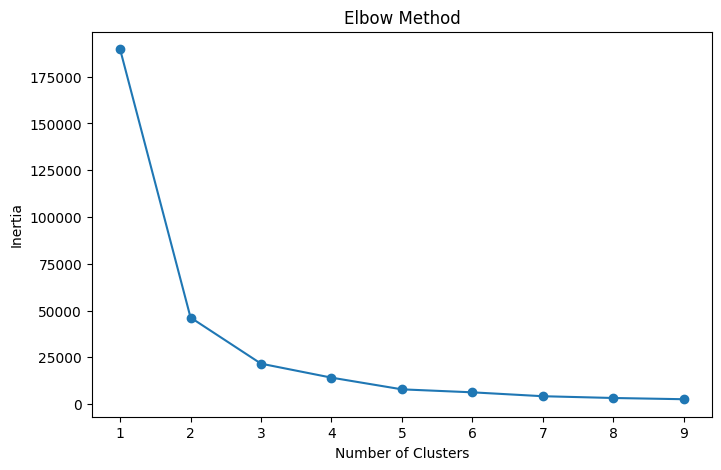

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Keep only numeric columns
X = df.select_dtypes(include=['int64','float64'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,date_time,series,source,Cluster
0,2018-07-01T05:00:00Z,45037,coal,1
1,2018-07-01T06:00:00Z,96248,coal,0
2,2018-07-01T07:00:00Z,94535,coal,0
3,2018-07-01T08:00:00Z,93672,coal,0
4,2018-07-01T09:00:00Z,89685,coal,0


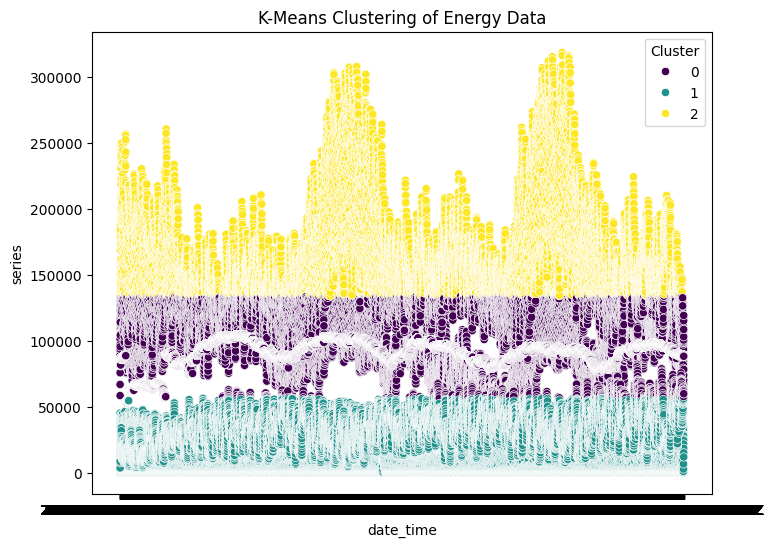

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x=df.columns[0],   # first feature
    y=df.columns[1],   # second feature
    hue="Cluster",
    palette="viridis"
)

plt.title("K-Means Clustering of Energy Data")
plt.show()

In [14]:
# Check if target exists
if "energy_source" in df.columns:

    y = df["energy_source"]

    # Encode labels
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y_encoded,
        test_size=0.2,
        random_state=42
    )

In [17]:
df.columns

Index(['date_time', 'series', 'source', 'Cluster'], dtype='str')

In [21]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

# Load dataset
data = load_iris()
X = data.data        # Features
y = data.target      # Target labels

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
df.to_csv("energy_clusters_output.csv", index=False)